In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
@tf.custom_gradient
def ternary_quantize(w):
    scale = tf.reduce_mean(tf.abs(w))
    scale = tf.maximum(scale, 1e-7)
    w_scaled = w / scale
    w_quant = tf.clip_by_value(tf.math.round(w_scaled), -1.0, 1.0)
    w_fake = w_quant * scale
    def grad(dy):
        return dy

    return w_fake, grad

In [ ]:
class BitConv2D(layers.Conv2D):
    def call(self, inputs):
        quantized_kernel = ternary_quantize(self.kernel)

        outputs = self.convolution_op(inputs, quantized_kernel)

        if self.use_bias:
            outputs = tf.nn.bias_add(outputs, self.bias, data_format=self._tf_data_format)

        if self.activation is not None:
            return self.activation(outputs)
        return outputs

class BitDense(layers.Dense):
    def call(self, inputs):
        quantized_kernel = ternary_quantize(self.kernel)

        outputs = tf.matmul(inputs, quantized_kernel)

        if self.use_bias:
            outputs = tf.nn.bias_add(outputs, self.bias)

        if self.activation is not None:
            return self.activation(outputs)
        return outputs

In [ ]:
def build_bitnet_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),

        layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),

        BitConv2D(64, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        BitConv2D(128, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),

        BitConv2D(128, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        BitConv2D(256, (3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(num_classes, use_bias=True)
    ])
    return model

model = build_bitnet_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bit_conv2d (BitConv2D)          │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bit_conv2d_1 (BitConv2D)        │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bit_conv2d_2 (BitConv2D)        │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bit_conv2d_3 (BitConv2D)        │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 540,394 (2.06 MB)

 Trainable params: 539,178 (2.06 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5
x_test = (x_test.astype('float32') - 127.5) / 127.5

print("Loading pre-trained ResNet50V2 teacher...")
base_teacher = tf.keras.applications.ResNet50V2(
    include_top=False,
    weights='imagenet',
    input_shape=(128, 128, 3),
    pooling='avg'
)

teacher_input = layers.Input(shape=(32, 32, 3))
x = layers.Resizing(128, 128)(teacher_input)
x = base_teacher(x, training=False)
teacher_output = layers.Dense(10)(x)
teacher_model = models.Model(teacher_input, teacher_output)
teacher_model.trainable = False

class Distiller(tf.keras.Model):
    def __init__(self, student, teacher):
        super(Distiller, self).__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.5, temperature=3.0):
        super(Distiller, self).compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        teacher_predictions = self.teacher(x, training=False)
        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_predictions)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1)
            )
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        gradients = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))
        self.compiled_metrics.update_state(y, student_predictions)
        return {m.name: m.result() for m in self.metrics}

distiller = Distiller(student=model, teacher=teacher_model)
distiller.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy'],
    student_loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=tf.keras.losses.KLDivergence(),
    alpha=0.5,
    temperature=3.0
)

print("Starting Distillation...")
distiller.fit(x_train, y_train, epochs=25, batch_size=64)

print("Final fine-tuning with scheduler...")
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=2e-4, decay_steps=10000)
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=40, validation_data=(x_test, y_test), batch_size=64)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1818s 11us/step
Loading pre-trained ResNet50V2 teacher...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting Distillation...
Epoch 1/25


/usr/local/lib/python3.13/dist-packages/keras/src/backend/tensorflow/trainer.py:670: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 92ms/step - accuracy: 0.5327 - loss: -0.0742
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.6653 - loss: -0.2529
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.7227 - loss: -0.3860
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 90ms/step - accuracy: 0.7536 - loss: -0.4911
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 90ms/step - accuracy: 0.7766 - loss: -0.5665
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.7958 - loss: -0.6311
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.8072 - loss: -0.6867
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 90ms/step - accuracy: 0.8190 - loss: -0.7356
Epoch 9/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.8287 - loss: -0.7746
Epoch 10/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 90ms/step - accuracy: 0.8384 - loss: -0.8119
Epoch 11/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.8456 - loss: -0.8444
Epoch 12/25
782/782 ━━━━━━━━━━

### Model Performance Visualization
We will now visualize the training metrics and analyze the errors using a confusion matrix.

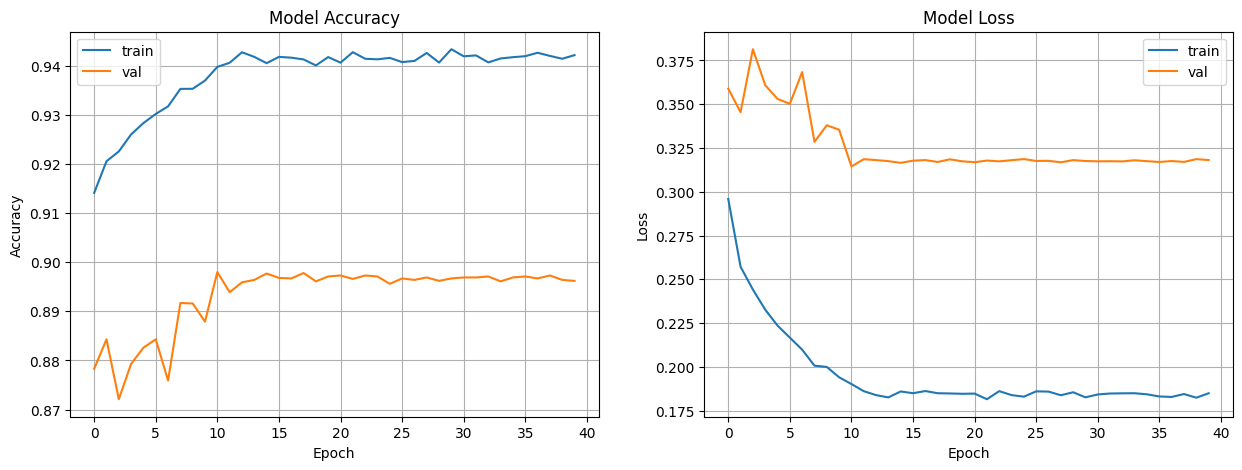

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history['accuracy'], label='train')
    ax1.plot(history.history['val_accuracy'], label='val')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'], label='train')
    ax2.plot(history.history['val_loss'], label='val')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.show()

plot_history(history)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


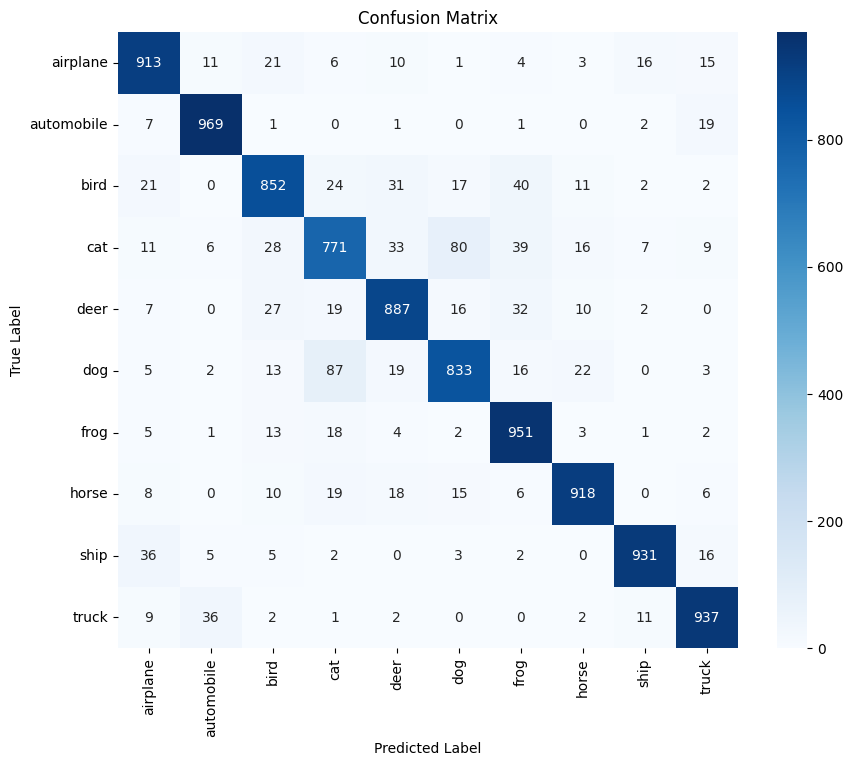


Classification Report:
              precision    recall  f1-score   support

    airplane       0.89      0.91      0.90      1000
  automobile       0.94      0.97      0.95      1000
        bird       0.88      0.85      0.86      1000
         cat       0.81      0.77      0.79      1000
        deer       0.88      0.89      0.88      1000
         dog       0.86      0.83      0.85      1000
        frog       0.87      0.95      0.91      1000
       horse       0.93      0.92      0.92      1000
        ship       0.96      0.93      0.94      1000
       truck       0.93      0.94      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [ ]:
def plot_confusion_matrix(model, x_test, y_test):
    y_pred_logits = model.predict(x_test, batch_size=128)
    y_pred = np.argmax(y_pred_logits, axis=1)

    classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=classes))

plot_confusion_matrix(model, x_test, y_test)

In [ ]:
import struct

def export_bitnet_weights(model, output_filename="model_weights.bin"):
    with open(output_filename, "wb") as f:

        def write_conv_layer(conv_layer, bn_layer, is_ternary=True):
            w = conv_layer.get_weights()[0]
            gamma, beta, mean, var = bn_layer.get_weights()
            eps = bn_layer.epsilon
            cout = w.shape[-1]

            if is_ternary:
                alpha = float(np.mean(np.abs(w)))
                w_scaled = np.clip(np.round(w / max(alpha, 1e-7)), -1.0, 1.0).astype(
                    np.int8
                )
            else:
                alpha = 1.0

            bn_scale = (gamma * alpha) / np.sqrt(var + eps)
            bn_bias = beta - (gamma * mean) / np.sqrt(var + eps)

            f.write(struct.pack("f", alpha))
            f.write(bn_scale.astype(np.float32).tobytes())
            f.write(bn_bias.astype(np.float32).tobytes())

            if is_ternary:
                flat_w = w_scaled.flatten()
                packed = bytearray()
                for i in range(0, len(flat_w), 4):
                    chunk = flat_w[i : i + 4]
                    byte = 0
                    for shift_idx, val in enumerate(chunk):
                        code = 1 if val == 1 else (2 if val == -1 else 0)
                        byte |= code << (shift_idx * 2)
                    packed.append(byte)
                f.write(packed)
            else:
                f.write(w.astype(np.float32).flatten().tobytes())

        write_conv_layer(model.layers[2], model.layers[3], is_ternary=False)
        write_conv_layer(model.layers[5], model.layers[6], is_ternary=True)
        write_conv_layer(model.layers[9], model.layers[10], is_ternary=True)
        write_conv_layer(model.layers[12], model.layers[13], is_ternary=True)
        write_conv_layer(model.layers[16], model.layers[17], is_ternary=True)

        dense_w, dense_b = model.layers[20].get_weights()
        f.write(struct.pack("f", 1.0))
        f.write(np.zeros(dense_w.shape[-1], dtype=np.float32).tobytes())
        f.write(dense_b.astype(np.float32).tobytes())
        f.write(dense_w.astype(np.float32).flatten().tobytes())

    print(f"[+] Successfully exported model weights to '{output_filename}'")


export_bitnet_weights(model, "model_weights.bin")

[+] Successfully exported model weights to 'model_weights.bin'


In [ ]:
model_weights_filename = 'bitnet_model_weights.weights.h5'
model.save_weights(model_weights_filename)
print(f'[+] Successfully saved Keras weights to {model_weights_filename}')

[+] Successfully saved Keras weights to bitnet_model_weights.weights.h5
